## CIFAR10 Image Classification

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import  DataLoader

import torchvision
from torchvision.datasets import CIFAR10 # Dataset to practice CNN => It has 10 Classes
from torchvision.transforms import transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# image => scale the image (0,1) => Normalise the image to scale (-1,1)

# Transformer
transform = transforms.Compose([
    transforms.ToTensor(), # Converts the imgs to pytorch tensor & scales them as well
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Values are fixed
])

# CIFAR10: Dataset to practice CNN => It has 10 Classes
trainset = CIFAR10(root=r"./Data", train=True, download=True, transform=transform)
testset = CIFAR10(root=r"./Data", train=False, download=True, transform=transform)

train_loader = DataLoader(trainset, batch_size=64, shuffle=True)
test_loader = DataLoader(testset, batch_size=64)

## Build CNN

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            # 1st conv_layer
            # i/p img dimensions: 32 X 32 X 3
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # in_channels,out_channels (check the calc.), conv kernel size, padding
            # in_channels for color imgs (RGB) is 3, and for black & white imgs is 1
            # In CIFAR10, the dimensions of i/p imgs are 32 X 32 X 3, i.e. row X col X channels
            # To calculate the output_channels, after applying the 1st conv_layer, we perform the following calculation
            # o/p dimension = (n-f+2p)/s + 1 
            # Here, n = dimension of i/p img, i.e. 32
            # f = dimensions of filter/kernel applied in conv layer, i.e. 3
            # p = padding applied in i/p img, i.e. 1
            # s = stride value used by filter/kernel in conv layer i.e. 1
            # out_channels/dimensions of o/p img = 32 X 32 X 32
            nn.ReLU(),
            # Pooling Layer
            nn.MaxPool2d(2, 2), # Kernel_size for pooling, stride value
            # Now the o/p img dimensions are 32/2 X 32/2 X 32, i.e. 16 X 16 X 32, after pooling

            # 2nd conv_layer
            # i/p img dimensions: 16 X 16 X 32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            # out_channels/dimensions of o/p img = 16 X 16 X 64
            nn.ReLU(),
            # Pooling Layer
            nn.MaxPool2d(2, 2),
            # Now the o/p img dimensions are 16/2 X 16/2 X 64, i.e. 8 X 8 X 64, after pooling

            # 3rd conv_layer
            # i/p img dimensions: 8 X 8 X 64
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            # out_channels/dimensions of o/p img = 8 X 8 X 128
            nn.ReLU(),
            # Pooling Layer
            nn.MaxPool2d(2, 2)
            # Now the o/p img dimensions are 8/2 X 8/2 X 128, i.e. 4 X 4 X 128, after pooling
        )

        self.fc_layers = nn.Sequential( # Similar to ANN

            # 1st Hidden Layers
            # After flattening the o/p img of dimensions 4 X 4 X 128, we get i/p values = 4*4*128
            nn.Linear(4*4*128, 256), # in_features, out_features => This time we are keeping 64 neurons in o/p
            nn.ReLU(),

            nn.Linear(256, 10), # We have kept out_features = 10, as total classes in CIFAR10 are 10
            # Softmax is internally applied by CrossEntropy Loss func()
            
        )

    # Forward Propagation
    def forward(self, x):
        x = self.conv_layers(x) # Output produced after Convolutional Layers & Pooling Layers are applied
        x = x.view(x.size(0), -1) # Flatten the Output
        x = self.fc_layers(x) # Output produced after Fully Connected Layers are applied

        return x

In [4]:
model = CNN()

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## Training CNN Model

In [6]:
epochs = 10
train_losses = []
valid_losses = []
best_val = float("inf")

for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in train_loader:
        model.train()
        optimizer.zero_grad()
        
        # Forward Propagation
        outputs = model.forward(images)
        # Apply Loss func()
        loss = criterion(outputs, labels) # Batch-wise loss
        # Backward propagation
        loss.backward()
        # Update the parameters
        optimizer.step()

        epoch_training_loss += loss.item() # Converts tensor dtype -> floating val, and then adds it up

    epoch_training_loss = epoch_training_loss/len(train_loader)
    train_losses.append(epoch_training_loss)

    # Validation
    model.eval()

    running_valid_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_valid_loss += loss.item()
        
    epoch_valid_loss = running_valid_loss/len(test_loader)
    valid_losses.append(epoch_valid_loss)

    # Saving & Loading the best model
    if epoch_valid_loss < best_val:
        best_val = epoch_valid_loss
        torch.save(model.state_dict(), "best_CNN_model.pt")

    print(f"Epoch: {epoch+1}/{epochs} => Train Loss: {epoch_training_loss} => Valid Loss: {epoch_valid_loss}")

Epoch: 1/10 => Train Loss: 1.3787273833971194 => Valid Loss: 1.0640059831036124
Epoch: 2/10 => Train Loss: 0.9368179310923037 => Valid Loss: 0.8582264105225824
Epoch: 3/10 => Train Loss: 0.751847115585871 => Valid Loss: 0.7840098970255275
Epoch: 4/10 => Train Loss: 0.6221790938731044 => Valid Loss: 0.7728133099094318
Epoch: 5/10 => Train Loss: 0.5227266938027824 => Valid Loss: 0.7036384520637002
Epoch: 6/10 => Train Loss: 0.43031043201075186 => Valid Loss: 0.7389964755553349
Epoch: 7/10 => Train Loss: 0.34582398248755414 => Valid Loss: 0.8253956216915398
Epoch: 8/10 => Train Loss: 0.27843138978094856 => Valid Loss: 0.8315072277928613
Epoch: 9/10 => Train Loss: 0.21358219075881307 => Valid Loss: 1.0138099125236462
Epoch: 10/10 => Train Loss: 0.16196797041417768 => Valid Loss: 1.0316447579556969


## Load the Best Model

In [7]:
model.load_state_dict(torch.load("best_CNN_model.pt"))

<All keys matched successfully>

In [8]:
idx = np.argmin(valid_losses)
print("Best Model Parameters")
print("Epoch:", idx+1)
print("Training Loss:", train_losses[idx])
print("Validation Loss:", valid_losses[idx])

Best Model Parameters
Epoch: 5
Training Loss: 0.5227266938027824
Validation Loss: 0.7036384520637002


## Visualising Losses

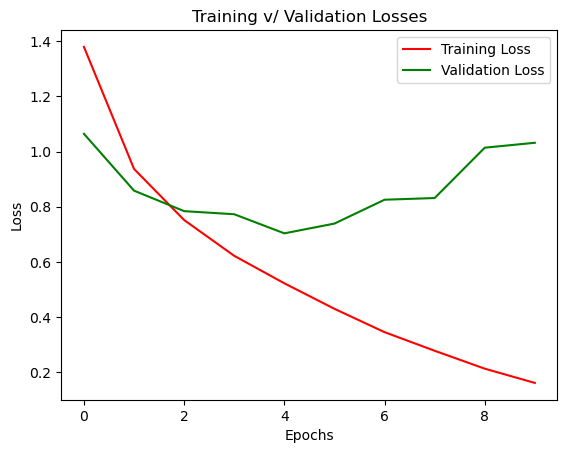

In [9]:
loss_df = pd.DataFrame({
    "Epoch": range(epochs),
    "Training_Loss": train_losses,
    "Validation_Loss": valid_losses
})

sns.lineplot(
    data = loss_df,
    x = "Epoch",
    y = "Training_Loss",
    color = "red",
    label = "Training Loss"
)

sns.lineplot(
    data = loss_df,
    x = "Epoch",
    y = "Validation_Loss",
    color = "green",
    label = "Validation Loss"
)

plt.title("Training v/ Validation Losses")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.savefig("loss_curve.png")
plt.show()

## Evaluate CNN

In [10]:
correct_labels = 0
total_labels = 0

all_labels = []
all_preds = []

model.eval()
with torch.no_grad():
    
    for images, labels in test_loader:
         outputs = model(images)
         _,predicted = torch.max(outputs, 1)
        
         correct_labels += (predicted == labels).sum().item()
         total_labels += labels.size(0)
        
         all_preds.extend(predicted.numpy())
         all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels, 
    all_preds, 
    average="weighted"
)

recall = recall_score(
    all_labels, 
    all_preds, 
    average="weighted"
)

f1 = f1_score(
    all_labels, 
    all_preds, 
    average="weighted"
)

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 75.93%
Precision: 0.7597
Recall: 0.7593
F1 Score: 0.7579


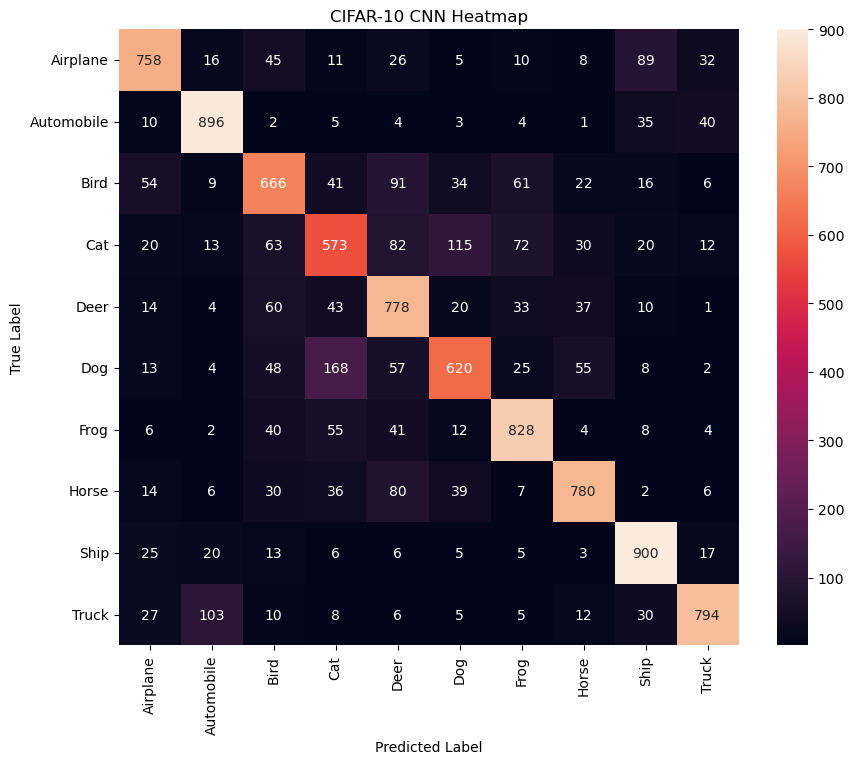

In [11]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

classes = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CIFAR-10 CNN Heatmap")

plt.savefig("heatmap.png")
plt.show()

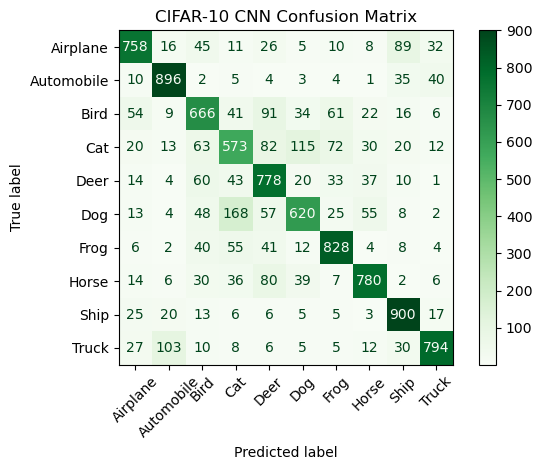

In [12]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

classes = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    cmap="Greens",
    xticks_rotation=45
)

plt.title("CIFAR-10 CNN Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()